In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# I somehow hate matplotlibs dark mode (I run a darkmode notebook), so I set it default
# dec 2022
plt.style.use('default') 

In [51]:
# This is the data from kaggle that we downloaded, and we put it in the same folder as this notebook
# It's a csv file, so we can use pandas to read it with read_csv. 
df = pd.read_csv('NetflixOriginals.csv')

In [52]:
# Always good to have a sanity check, so we can see the first 5 rows of the data
df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi


## What are some questions we want to ask?

One of the first things when doing EDA is to consider questions that you would like to know the answer to from the data.
For example in this case, we might want to know:

1. What are the most popular genres?
2. What are the most popular movies?
3. Is there any relationship between the number of movies and the year?
4. Is there any variable that seems to correlate with the rating of a movie?


You should write a big list of questions! whatever comes to mind just looking at the first 5 rows.
Then you can start to think about how you might answer those questions.



In [53]:
# Let's try to understand the first question.
# What are the most popular genres?
# We can see that the genres are in a column called 'Genre'
# We can use the value_counts() function to count the number of times each genre appears

df['Genre'].value_counts()

Genre
Documentary                             159
Drama                                    77
Comedy                                   49
Romantic comedy                          39
Thriller                                 33
                                       ... 
Action-adventure                          1
Animation / Science Fiction               1
Anthology/Dark comedy                     1
Musical / Short                           1
Animation/Christmas/Comedy/Adventure      1
Name: count, Length: 115, dtype: int64

In [54]:
# The above output isn't a bit too long to read.
# But I'm noticing that some genres are repeated, but with different capitalization, this may be something I can clean later
# For the time being, I want to see if I can find a list of all the genres that have more than 1 occurence

# We can use a boolean mask to do this
# A boolean mask is a list of True/False values that we can use to filter our data

mask = df['Genre'].value_counts() > 1 # this will return a mask of True/False values
df['Genre'].value_counts()[mask] # this will return the value counts of the genres that have more than 1 occurence

# After this prints out you may decide you need to change the number of occurences.

Genre
Documentary                 159
Drama                        77
Comedy                       49
Romantic comedy              39
Thriller                     33
Comedy-drama                 14
Crime drama                  11
Horror                        9
Biopic                        9
Action                        7
Aftershow / Interview         6
Concert Film                  6
Romance                       6
Action comedy                 5
Romantic drama                5
Animation                     5
Science fiction/Thriller      4
Variety show                  4
Science fiction               4
Psychological thriller        4
Animation / Short             4
One-man show                  3
Sports-drama                  3
Action-thriller               3
Science fiction/Drama         3
Horror thriller               3
Western                       3
Dark comedy                   2
Mystery                       2
Family film                   2
Black comedy                  2
Co

<Axes: title={'center': 'Most Popular Genres'}, xlabel='Genre', ylabel='Number of Occurences'>

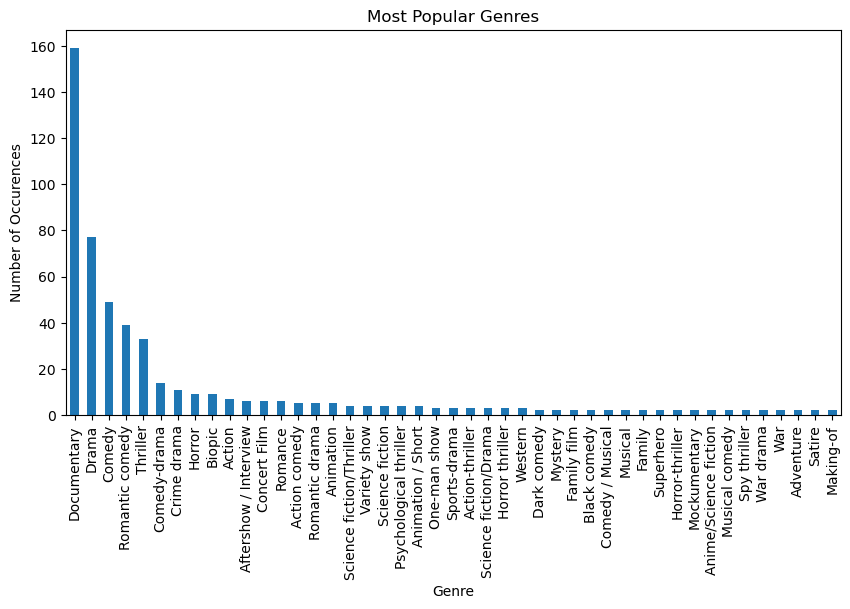

In [55]:
# Now that we have a list of genres that have more than 1 occurence, we can plot them
# We can use the plot() function to plot the value counts of the genres that have more than 1 occurence
# We can also use the kind parameter to specify the type of plot we want
# We can use the figsize parameter to specify the size of the plot
# We can use the title parameter to specify the title of the plot
# We can use the xlabel parameter to specify the x axis label of the plot
# We can use the ylabel parameter to specify the y axis label of the plot

df['Genre'].value_counts()[mask].plot(kind='bar', figsize=(10, 5), title='Most Popular Genres', xlabel='Genre', ylabel='Number of Occurences')

But wait, this tells me which genre repeated the most, not which one had a high IMDB rating. Let's try to find the highest rated genre.

In [56]:
# We need to group the data by genre and then find the mean of the IMDB Score
# First we need to group the data by genre, this makes "groups" of data for each genre
# Then we need to find the mean of the IMDB Score for each group
# Then we need to sort the data by the mean of the IMDB Score
# We want to sort the data in descending order, so we need to set the ascending parameter to False
# Then we need to get the first 10 rows of the data
df.groupby('Genre')['IMDB Score'].mean().sort_values(ascending=False).head(10)

Genre
Animation/Christmas/Comedy/Adventure    8.200000
Musical / Short                         7.700000
Concert Film                            7.633333
Anthology/Dark comedy                   7.600000
Animation / Science Fiction             7.500000
Making-of                               7.450000
Action-adventure                        7.300000
Drama-Comedy                            7.200000
Historical drama                        7.200000
Coming-of-age comedy-drama              7.200000
Name: IMDB Score, dtype: float64

 Now you try finding the movie languages with the highest IMDB Score, you can use the same pattern as above.

In [57]:
df.groupby('Language')['IMDB Score'].mean().sort_values(ascending=False).head(10)

Language
English/Ukranian/Russian    8.4
English/Akan                7.7
English/Hindi               7.3
English/Arabic              7.3
English/Korean              7.3
English/Russian             7.3
Spanish/English             7.3
Khmer/English/French        7.2
Tamil                       7.2
Bengali                     7.1
Name: IMDB Score, dtype: float64

# It's your turn now.

Now we want you to go ahead and try to answer your own questions. A few big things are going to happen.

1. You will get stuck
2. You won't know what to do
3. You will get frustrated

This is all normal! This is how everyone learns to program and do data science. Just like chess has nearly infinite branching factors, learning to do data science has a similar branching factor. We cannot teach you every branch, you will encounter many things you have not been shown how to do. That's ok! Our hope is that you will learn how to learn, and that you will learn how to find the answers to your questions.

More importantly, we are here for you on discord, waiting to answer your questions. Please ask us questions! We are here to help you learn.

Some last tips of advice.

1. You can start by just adjusting existing code patterns you have already seen.
2. When you have a big question, try to break it into small tasks. For example if my question is "3. Is there any relationship between the number of movies and the year?" Then I will want to break that into smaller tasks. I might start with "How do I get the number of movies per year?" and then "How do I plot the number of movies per year?" and then "How do I plot the number of movies per year in a way that I can see the relationship between the number of movies and the year?" Keep breaking things into smaller tasks and doing them. Then put it all together.

Good luck! We are here to help you!


What is the average runtime per genre?

In [58]:
runtime_per_genre = df.groupby('Genre')['Runtime'].mean().sort_values(ascending=False)
runtime_per_genre.head(10)

Genre
Anthology/Dark comedy           149.0
Heist film/Thriller             149.0
Zombie/Heist                    148.0
War drama                       145.5
Horror anthology                144.0
Psychological thriller drama    142.0
Historical drama                140.0
Science fiction/Mystery         126.0
Psychological thriller          124.0
Superhero/Action                124.0
Name: Runtime, dtype: float64

<Axes: title={'center': 'Average Runtime per Genre'}, xlabel='Genre', ylabel='Average Runtime (minutes)'>

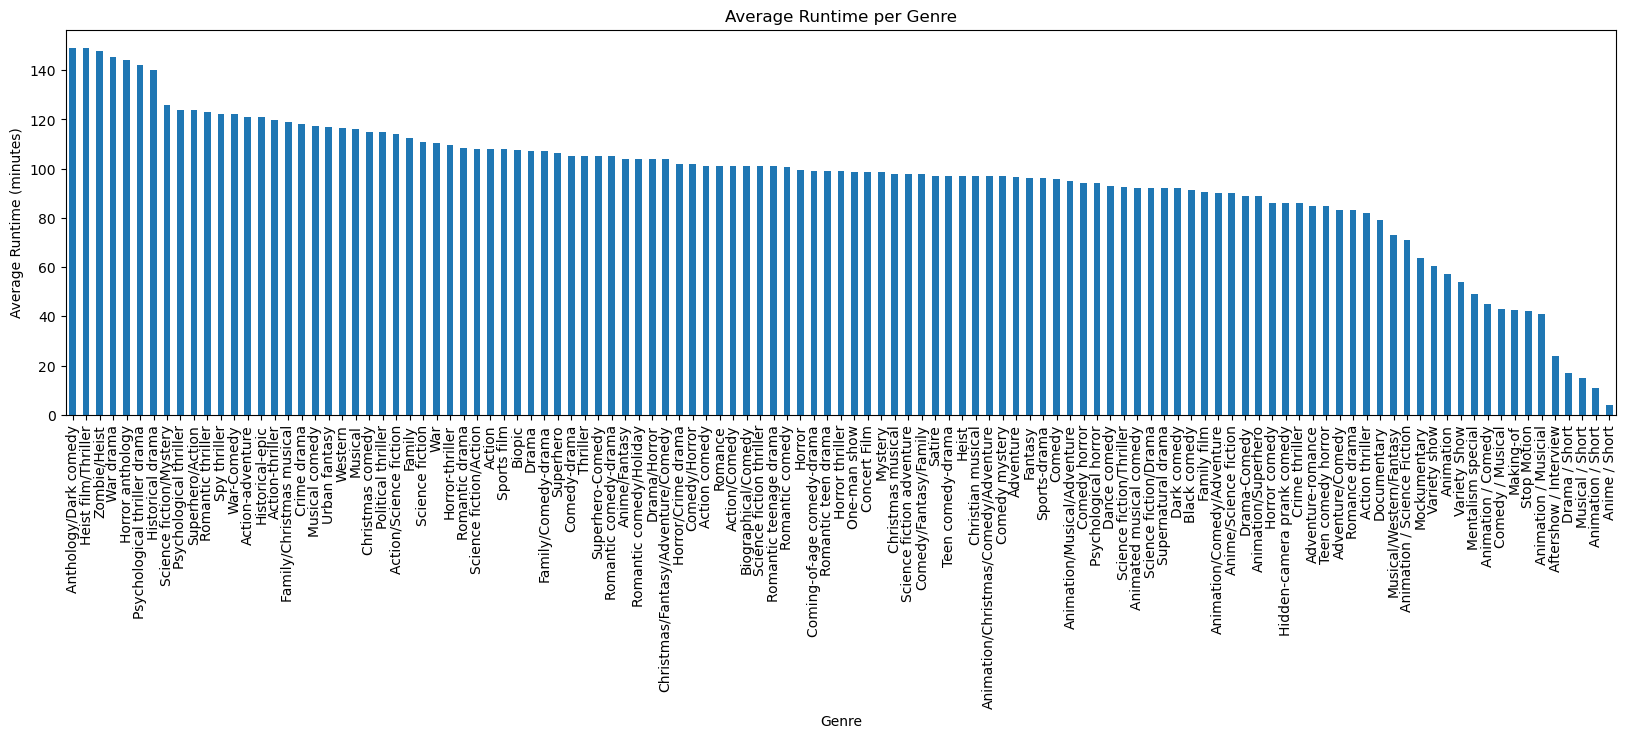

In [59]:
runtime_per_genre.plot(kind='bar', figsize=(20, 5), title='Average Runtime per Genre', xlabel='Genre', ylabel='Average Runtime (minutes)')

Is there any relationship between the number of movies and the year?

<Axes: title={'center': 'Number of Movies Released per Year'}, xlabel='Year', ylabel='Number of Movies'>

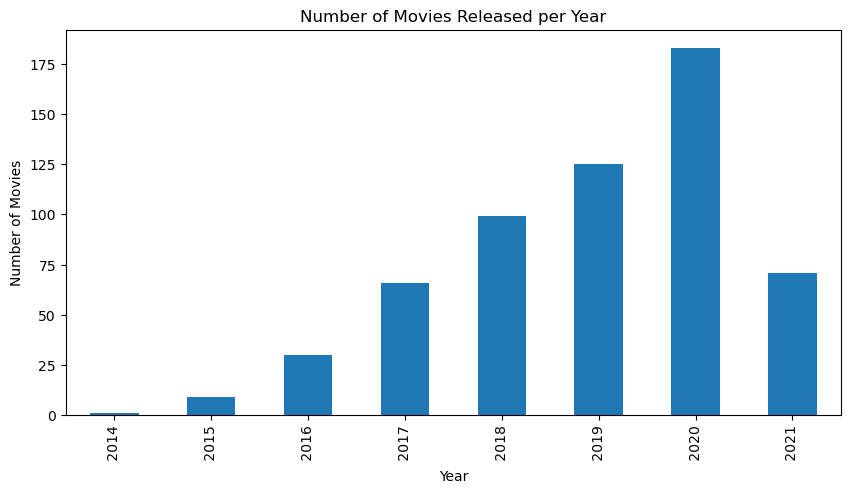

In [60]:
# get the year from the release date, which is in the format "Month Day, Year" or "Month Day. Year"
def get_year(release_date):
    if ',' in release_date:
        return release_date.split(',')[-1]
    if '.' in release_date:
        return release_date.split('.')[-1]
    return None

df['Year'] = df['Premiere'].apply(get_year)
movies_per_year = df['Year'].value_counts().sort_index()
movies_per_year.plot(kind='bar', figsize=(10, 5), title='Number of Movies Released per Year', xlabel='Year', ylabel='Number of Movies')

In [61]:
# convert movies_per_year to a dataframe to calculate the correlation between year and number of movies
df_yearly = movies_per_year.reset_index()
df_yearly.columns = ['Year', 'Number of Movies']
print(df_yearly)

    Year  Number of Movies
0   2014                 1
1   2015                 9
2   2016                30
3   2017                66
4   2018                99
5   2019               125
6   2020               183
7   2021                71


In [62]:
# a comparison of the correlation between year and number of movies using Pearson, Spearman, and Kendall correlation coefficients
corr_Pearson = df_yearly['Year'].corr(df_yearly['Number of Movies'])
corr_Spearman = df_yearly['Year'].corr(df_yearly['Number of Movies'], method='spearman')
corr_Kendall = df_yearly['Year'].corr(df_yearly['Number of Movies'], method='kendall')
print(f'Pearson Correlation between Year and Number of Movies: {corr_Pearson:.2f}')
print(f'Spearman Correlation between Year and Number of Movies: {corr_Spearman:.2f}')
print(f'Kendall Correlation between Year and Number of Movies: {corr_Kendall:.2f}')

Pearson Correlation between Year and Number of Movies: 0.79
Spearman Correlation between Year and Number of Movies: 0.86
Kendall Correlation between Year and Number of Movies: 0.79


What is the average imbd rating per movie language?

In [63]:
# we see that some movies have multiple languages, so we need to split the languages and count them separately
print(df['Language'].unique())

['English/Japanese' 'Spanish' 'Italian' 'English' 'Hindi' 'Turkish'
 'Korean' 'Indonesian' 'Malay' 'Dutch' 'French' 'English/Spanish'
 'Portuguese' 'Filipino' 'German' 'Polish' 'Norwegian' 'Marathi' 'Thai'
 'Swedish' 'Japanese' 'Spanish/Basque' 'Spanish/Catalan' 'English/Swedish'
 'English/Taiwanese/Mandarin' 'Thia/English' 'English/Mandarin' 'Georgian'
 'Bengali' 'Khmer/English/French' 'English/Hindi' 'Tamil'
 'Spanish/English' 'English/Korean' 'English/Arabic' 'English/Russian'
 'English/Akan' 'English/Ukranian/Russian']


In [64]:
def split_languages(languages):
    languages_list = languages.split('/')
    return languages_list

languages = df['Language'].apply(split_languages)
df_lang_rating = pd.DataFrame({'Language': languages, 'IMDB Score': df['IMDB Score']})
df_lang_rating = df_lang_rating.explode('Language')
print(df_lang_rating)

       Language  IMDB Score
0       English         2.5
0      Japanese         2.5
1       Spanish         2.6
2       Italian         2.6
3       English         3.2
..          ...         ...
580    Ukranian         8.4
580     Russian         8.4
581     English         8.5
582  Portuguese         8.6
583     English         9.0

[610 rows x 2 columns]


In [65]:
mean_per_leanguage = df_lang_rating.groupby('Language')['IMDB Score'].mean()
print(mean_per_leanguage)

Language
Akan          7.700000
Arabic        7.300000
Basque        5.600000
Bengali       7.100000
Catalan       6.400000
Dutch         5.800000
English       6.396209
Filipino      5.100000
French        5.838095
Georgian      6.800000
German        5.640000
Hindi         6.057143
Indonesian    5.844444
Italian       5.542857
Japanese      5.900000
Khmer         7.200000
Korean        6.114286
Malay         4.200000
Mandarin      6.866667
Marathi       6.066667
Norwegian     5.100000
Polish        5.166667
Portuguese    6.216667
Russian       7.850000
Spanish       6.302564
Swedish       6.000000
Taiwanese     6.500000
Tamil         7.200000
Thai          5.450000
Thia          6.700000
Turkish       5.660000
Ukranian      8.400000
Name: IMDB Score, dtype: float64


<Axes: title={'center': 'Average IMDB Score per Language'}, xlabel='Language', ylabel='Average IMDB Score'>

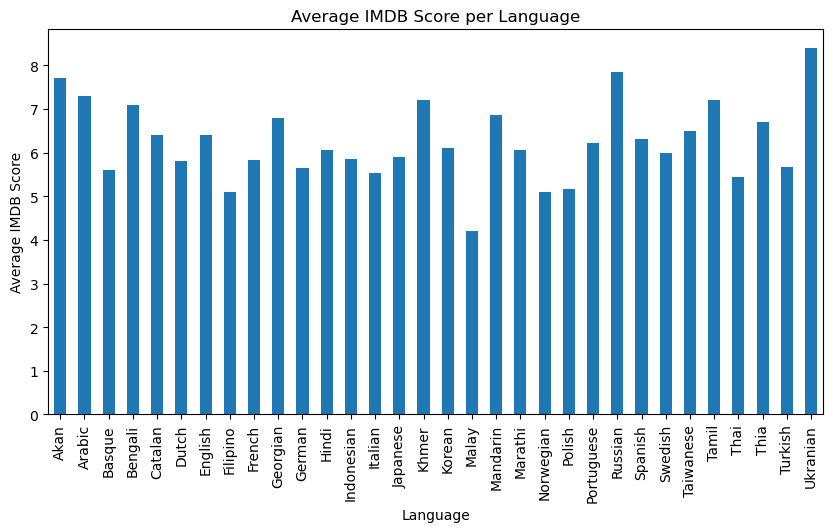

In [66]:
mean_per_leanguage.plot(kind='bar', figsize=(10, 5), title='Average IMDB Score per Language', xlabel='Language', ylabel='Average IMDB Score')

Box plot for IMBD Rating

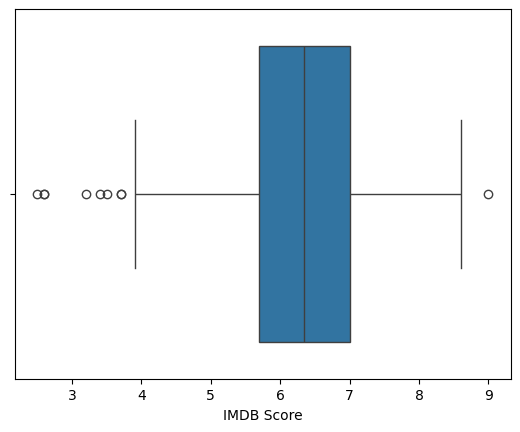

In [67]:
sns.boxplot(x='IMDB Score', data=df)
plt.show()

Is any relation beetween the lenght of the film and its IMDB rating?    

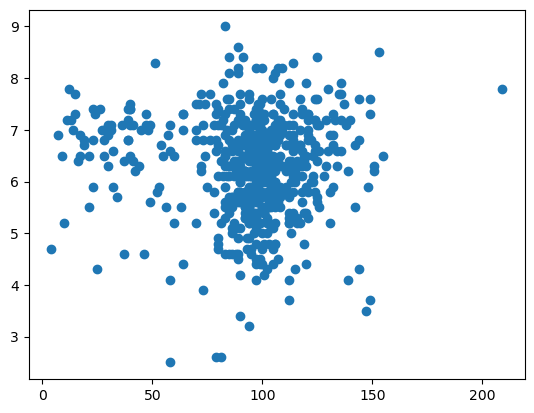

In [68]:
plt.scatter(df['Runtime'], df['IMDB Score'])

In [69]:
corr = df['Runtime'].corr(df['IMDB Score'])
print(f'Correlation between Runtime and IMDB Score: {corr:.2f}')

Correlation between Runtime and IMDB Score: -0.04


What is the most popular genre for every year?

In [70]:
genres_per_year = df.groupby('Year')['Genre'].value_counts().sort_values(ascending=False)
most_popular_genre_per_year = genres_per_year.groupby('Year').head(1).sort_index()
print(most_popular_genre_per_year)

Year  Genre      
2014  Documentary     1
2015  Documentary     6
2016  Documentary    12
2017  Documentary    22
2018  Documentary    25
2019  Documentary    40
2020  Documentary    39
2021  Drama          18
Name: count, dtype: int64


What is the month with the most films?

In [71]:
# we need to get the month from the release date
def get_month(release_date):
    if ',' in release_date:
        split_char = ','
    elif '.' in release_date:
        split_char = '.'
    else:
        return None

    month = release_date.split(split_char)[0].strip().split(' ')[0]

    return month


df['Month'] = df['Premiere'].apply(get_month)
print(df['Month'].value_counts())

Month
October      77
April        63
November     57
September    53
May          53
December     51
March        48
February     39
January      37
August       37
June         35
July         34
Name: count, dtype: int64


Are the movies with a runtime more than 2 hours good?

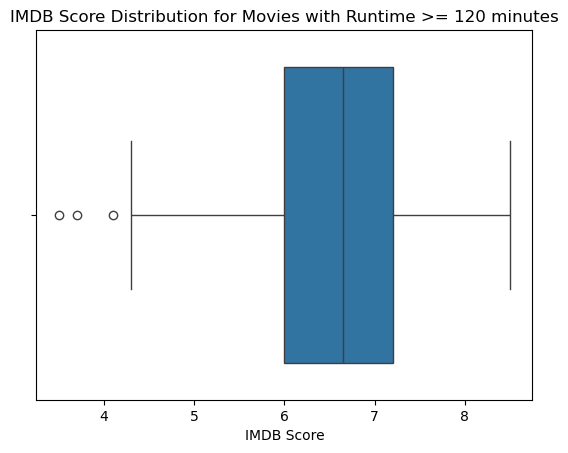

In [72]:
long_movies = df[df['Runtime'] >= 120]
fig, ax = plt.subplots()
sns.boxplot(x='IMDB Score', data=long_movies, ax=ax)
ax.set_title('IMDB Score Distribution for Movies with Runtime >= 120 minutes')
ax.set_xlabel('IMDB Score')
plt.show()

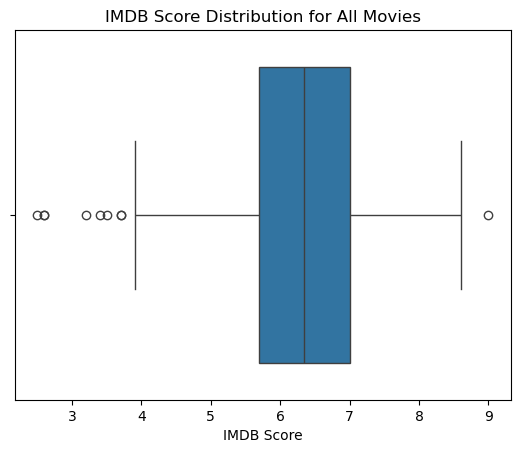

In [73]:
fig, ax = plt.subplots()
sns.boxplot(x='IMDB Score', data=df, ax=ax)
ax.set_title('IMDB Score Distribution for All Movies')
ax.set_xlabel('IMDB Score')
plt.show()

In [75]:
# from the boxplots we can see that the distribution of IMDB scores for movies with runtime >= 120 minutes is slightly higher than the distribution of IMDB scores for all movies.
# we can say that longer movies tend to slightly have higher IMDB scores than shorter ones.

avg_score = df['IMDB Score'].mean()
avg_score_long_movies = long_movies['IMDB Score'].mean()
print(f'Average IMDB Score for All Movies: {avg_score:.2f}')
print(f'Average IMDB Score for Movies with Runtime >= 120 minutes: {avg_score_long_movies:.2f}')
print(f'Diference in Average IMDB Score: {avg_score_long_movies - avg_score:.2f}')

Average IMDB Score for All Movies: 6.27
Average IMDB Score for Movies with Runtime >= 120 minutes: 6.55
Diference in Average IMDB Score: 0.28


Histogram of IMDB Scores

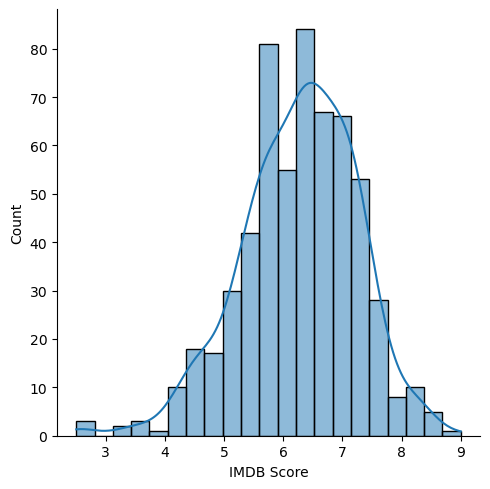

In [76]:
sns.displot(df['IMDB Score'], kde=True)